here 3600.0000000000005
here 3600.000000000001


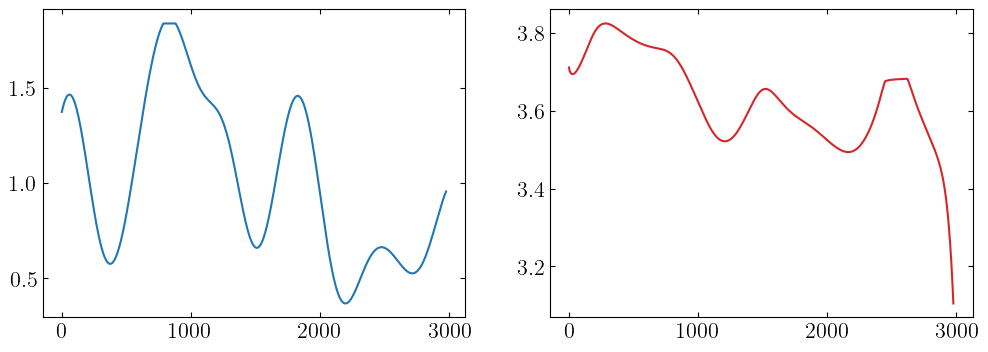

In [358]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
import time
import sys
import pybamm
import importlib

sys.path.append('..')
import plot_settings
plot_settings.apply()


import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm_ver3
importlib.reload(exp_pybamm_ver3)


from IPython.display import display, Math


s,m,p = sim_PyBaMM.simulate_GRF()

t = np.linspace(0, s['Time [s]'].entries[-1], 1000)
#print(t[-1])
I = s.observe(m.variables['Current [A]'])(t)
V = s.observe(m.variables['Terminal voltage [V]'])(t)

f, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(t, I, label='Current [A]')
ax[1].plot(t, V, label='Voltage [V]', color='tab:red')

In [359]:
from pysr import PySRRegressor, TemplateExpressionSpec
# import mean
from pysr import jl
jl.seval("using Statistics")

### Procedure

1. Find peaks of $\Delta I$ at $t_0$
2. Extract $c(t0+\Delta t)$ 
3. Use $I,t$ as inputs and compare to $c$


In [360]:
dI = np.load('data_c_dot2.npz')['I_dot'] 
dc = np.load('data_c_dot2.npz')['cn_dot'] / p['Maximum concentration in negative electrode [mol.m-3]']

In [361]:
dI = dI.reshape(dI.shape[0],dI.shape[1])
dc = dc.reshape(dc.shape[0],dc.shape[1])

Text(0, 0.5, '$\\dot{I}$')

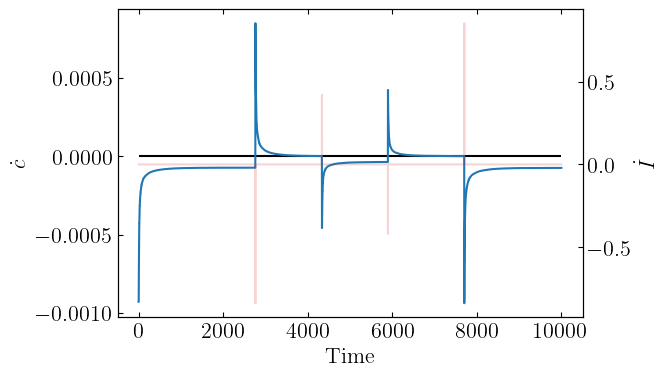

In [362]:
f, ax = plt.subplots(figsize=(6,4))
ax.hlines(0,0,dc.shape[1], label = 'Steady state', color = 'black')
ax.plot(dc[0,:])
axt = ax.twinx()
axt.plot(dI[0,:],color = 'tab:red',alpha = 0.2)
ax.set_xlabel('Time')
ax.set_ylabel(r'$\dot{c}$')
axt.set_ylabel(r'$\dot{I}$')

In [377]:
peak_idx = np.where(dI[:,:]<-0.1,1,0)

lag = 1000
dc_decays = []
dI_decay = []
for j,row in enumerate(peak_idx):
    short_idx = np.where(row==1)[0]
    for i in short_idx:
        if i+lag < dc.shape[1]:
            dc_decays = np.append(dc_decays,dc[j,i:i+lag].flatten())
            dI_decay = np.append(dI_decay,dI[j,i] * np.ones(lag))

decays = dc_decays.reshape(int(dc_decays.shape[0]/lag),lag)
dI_decay = dI_decay.reshape(int(dI_decay.shape[0]/lag),lag)

t_decay =np.ones_like(decays) * (np.arange(lag)+1) / 10
inputs = dI_decay

X = np.column_stack([
    dI_decay.flatten(),
    t_decay.flatten()
])

y = decays.flatten()

y.shape, decays.shape

((41000,), (41, 1000))

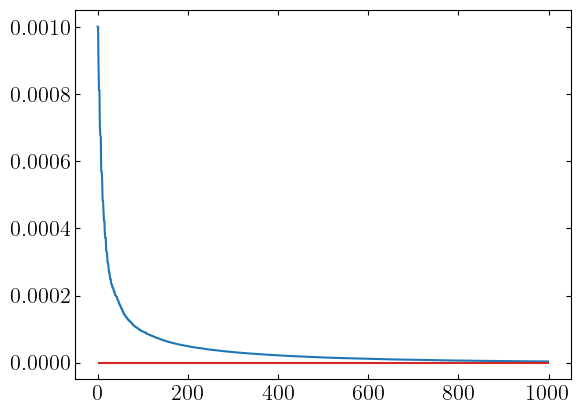

In [364]:
plt.plot(decays[5,:], label = 'Data')
plt.hlines(0,0,lag, label = 'Steady state', color = 'tab:red')

Text(0, 0.5, '$\\dot{I}$')

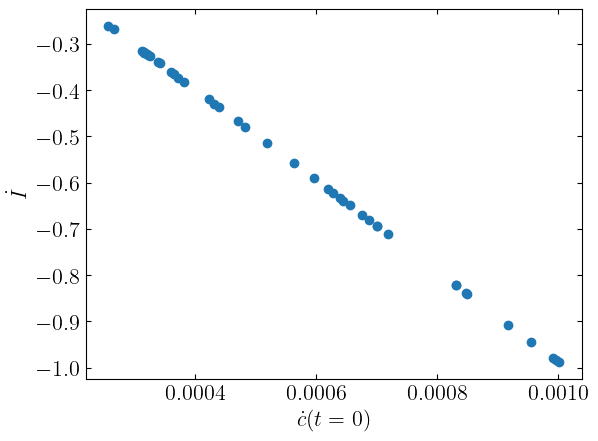

In [365]:
plt.scatter(decays[:,0],dI_decay[:,0], label = 'Data')
plt.xlabel(r'$\dot{c}(t = 0)$')
plt.ylabel(r'$\dot{I}$')

In [366]:
# template = TemplateExpressionSpec(
#     expressions=['f', 'g','h'],
#     variable_names=["x0", "x1"],
#     combine = 'f(x0) * exp(g(x1)) + h(x0,x1)' 
# )

In [367]:
model = PySRRegressor(
    model_selection="score",
    niterations=200,
    binary_operators=[
        "+", "*", '-','/'
    ],
    unary_operators=['exp','sqrt'],
    elementwise_loss="loss(x, y) = mean((x - y).^2)",
    populations=15,
    verbosity=1, 
    batching = True,
    batch_size = 1000,
    maxsize = 20,
)

In [368]:
model.fit(X, y)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 6.290e+03
Progress: 539 / 3000 total iterations (17.967%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.582e-09  0.000e+00  y = 2.5339e-05
3           2.127e-09  2.607e-01  y = 0.00011507 / x₁
4           1.149e-09  6.153e-01  y = 0.00020298 / sqrt(x₁)
5           5.933e-10  6.614e-01  y = 0.00056476 / (x₁ - -0.88965)
6           5.098e-10  1.516e-01  y = 0.00056476 / (x₁ + exp(x₀))
7           1.022e-10  1.607e+00  y = (x₀ / (-0.6467 - x₁)) * 0.0010034
9           1.706e-11  8.954e-01  y = (x₀ / ((x₁ - -0.83298) * -0.17753)) * 0.00017861
13          1.322e-11  6.371e-02  y = x₀ * ((0.0012154 / ((0.84675 - (x₁ + 1.7511)) / 0.8693...
                                      1)) + 3.3177e-06)
15          1.208e-11  4.516e-02  y = -1.2212 * ((-3.831

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'score'
,binary_operators,"['+', '*', ...]"
,unary_operators,"['exp', 'sqrt']"
,expression_spec,None
,niterations,200
,populations,15
,population_size,27
,max_evals,None
,maxsize,20
,maxdepth,None
,warmup_maxsize_by,None


  - outputs/20260227_132049_gxIdRS/hall_of_fame.csv


In [369]:
model_index = None
display(Math('\\Large '+ model.latex(model_index)))

<IPython.core.display.Math object>

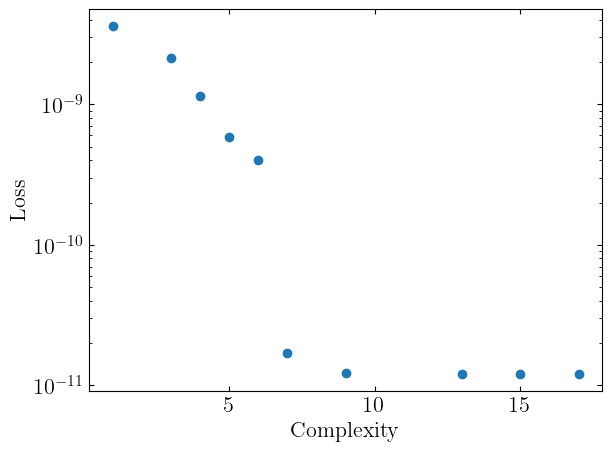

In [370]:
df = model.equations_


plt.scatter(df['complexity'], df['loss'])

plt.yscale('log')
plt.xlabel('Complexity')
plt.ylabel('Loss')

plt.tight_layout()

In [375]:
def f_decay(X, a,b,c):
    return X[:,0]* (a/ (b + (X[:,1])))

import scipy.optimize as opt

print(X.shape)
popt, pcov = opt.curve_fit(f_decay, X, y)

print(popt)



/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_54234/354503274.py:7: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = opt.curve_fit(f_decay, X, y)


(41000, 2)
[-9.98192639e-04  8.20948927e-01  1.00000000e+00]


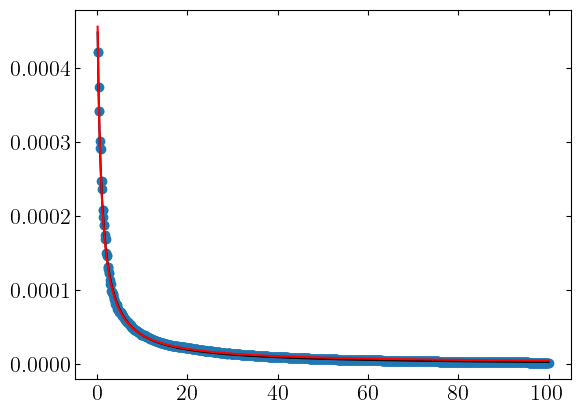

In [372]:

j = 1
X_fit = np.column_stack([
    dI_decay[j,:].flatten(),
    t_decay[j,:].flatten()
])
plt.scatter(X_fit[:,1],decays[j,:])


plt.plot(X_fit[:,1], f_decay(X_fit, *popt), color = 'k', label = 'Curve fit' )
plt.plot(X_fit[:,1], model.predict(X_fit), color = 'r', label = 'Symbolic regression' )

#plt.plot(X[ind,1], f_decay(X[ind,:], *popt), color = 'k', label = 'Curve fit' )

In [373]:
y_pred = model.predict(X)
y_pred = y_pred.reshape(decays.shape[0],decays.shape[1])    

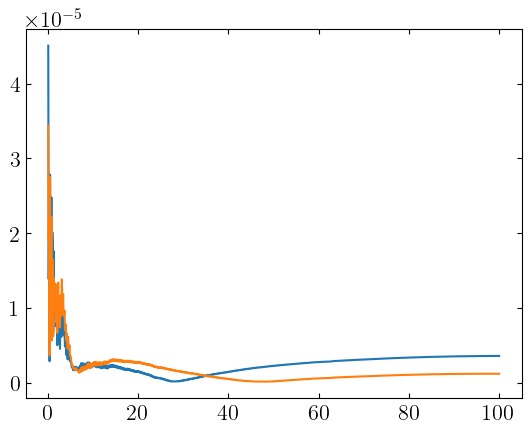

In [374]:
e_mean = np.mean(np.abs(y_pred - decays),axis = 0)
e_fit = np.abs(f_decay(X, *popt).reshape(decays.shape[0],decays.shape[1]) - decays)
plt.plot(t_decay[0,:],e_mean)
plt.plot(t_decay[0,:],e_fit.mean(axis = 0), label = 'Curve fit error')